# NB10 — Offline RL (Multi-Session, User 2)

Revisits the RL failure from NB05 with proper data volume: 11 sessions (~54k rows).  
**Key changes vs NB05:**
- Binary action space only (Hold=0, Raise=1) — Lower never observed
- 11 sessions (train 1–10, eval 12–13) vs single session in NB05  
- ~54k samples vs 3,549 in NB05 — sufficient for FQI Bellman iterations  
- Per-session normalised features from NB08

**Algorithms:** LinUCB (alpha=0.3) + FQI (10 Bellman iterations)  
**Evaluation:** IPS (Importance-weighted Policy Score)

In [1]:
import numpy as np
import pandas as pd
import json
import pickle
import warnings
import matplotlib
import matplotlib.pyplot as plt
from pathlib import Path
from sklearn.linear_model import Ridge
from sklearn.preprocessing import StandardScaler

try:
    import lightgbm as lgb
    HAS_LGBM = True
except ImportError:
    HAS_LGBM = False
    print('WARNING: lightgbm not installed — FQI will use Ridge fallback')

warnings.filterwarnings('ignore')

NEROES_PALETTE = {
    'bg':      '#0d1117',
    'surface': '#161b22',
    'cyan':    '#00c8ff',
    'teal':    '#00e5c3',
    'orange':  '#ff6b35',
    'yellow':  '#ffd700',
    'muted':   '#8b949e',
    'white':   '#e6edf3',
}

matplotlib.rcParams.update({
    'figure.facecolor':  NEROES_PALETTE['bg'],
    'axes.facecolor':    NEROES_PALETTE['surface'],
    'axes.edgecolor':    NEROES_PALETTE['muted'],
    'axes.labelcolor':   NEROES_PALETTE['white'],
    'xtick.color':       NEROES_PALETTE['muted'],
    'ytick.color':       NEROES_PALETTE['muted'],
    'text.color':        NEROES_PALETTE['white'],
    'grid.color':        NEROES_PALETTE['muted'],
    'grid.alpha':        0.2,
    'figure.dpi':        120,
})

PROJECT_ROOT  = Path('..').resolve()
PROCESSED_DIR = PROJECT_ROOT / 'data' / 'processed'
FIGURES_DIR   = PROJECT_ROOT / 'outputs' / 'figures'
OUTPUTS_DIR   = PROJECT_ROOT / 'outputs'
FIGURES_DIR.mkdir(parents=True, exist_ok=True)

RNG = np.random.default_rng(42)
print('Setup complete.')

Setup complete.


## Section 1 — Load Features and Build RL Dataset

In [2]:
df = pd.read_parquet(PROCESSED_DIR / 'user2_features.parquet')
with open(PROCESSED_DIR / 'user2_feature_meta.json') as f:
    meta = json.load(f)

FEATURE_COLS   = meta['feature_cols']
ACTION_COL     = meta['action_col']   # 'action_binary'
REWARD_COL     = meta['reward_col']   # 'reward'
N_ACTIONS      = meta['n_actions']    # 2
ACTION_MAP     = {int(k): v for k, v in meta['action_map'].items()}
TRAIN_SESSIONS = meta['train_sessions']
TEST_SESSIONS  = meta['test_sessions']

print(f'Loaded: {df.shape[0]:,} rows × {df.shape[1]} cols')
print(f'Actions: {ACTION_MAP}')
print(f'Features: {len(FEATURE_COLS)}')

# Build RL transitions: (s, a, r, s') — exclude baseline subsessions and NaN actions
game_df = df[
    (df['subsession'] > 0) &
    df[ACTION_COL].notna() &
    df[REWARD_COL].notna()
].copy()

game_df[ACTION_COL] = game_df[ACTION_COL].astype(int)

# Action distribution
print('\nAction distribution in game subsessions:')
for a in sorted(game_df[ACTION_COL].unique()):
    n = (game_df[ACTION_COL] == a).sum()
    print(f'  {a} ({ACTION_MAP.get(a,"?")}): {n:,} ({100*n/len(game_df):.1f}%)')

Loaded: 50,194 rows × 82 cols
Actions: {0: 'Hold', 1: 'Raise'}
Features: 59

Action distribution in game subsessions:
  0 (Hold): 42,087 (93.8%)
  1 (Raise): 2,775 (6.2%)


## Section 2 — Train / Eval Split

In [3]:
train_df = game_df[game_df['session_id'].isin(TRAIN_SESSIONS)].copy()
eval_df  = game_df[game_df['session_id'].isin(TEST_SESSIONS)].copy()

print(f'Train: {len(train_df):,} rows')
print(f'Eval:  {len(eval_df):,} rows')

def prep_xy(data):
    """Returns (X, actions, rewards) with NaN filled."""
    X = data[FEATURE_COLS].fillna(0).values.astype(np.float32)
    a = data[ACTION_COL].values.astype(int)
    r = data[REWARD_COL].values.astype(np.float32)
    return X, a, r

X_train, a_train, r_train = prep_xy(train_df)
X_eval,  a_eval,  r_eval  = prep_xy(eval_df)

# Logged policy (empirical frequency)
logged_probs = np.zeros((len(X_train), N_ACTIONS))
for a in range(N_ACTIONS):
    logged_probs[:, a] = (a_train == a).mean()

print(f'\nLogged policy (empirical): Hold={logged_probs[0,0]:.3f}, Raise={logged_probs[0,1]:.3f}')

# Scale features
scaler = StandardScaler()
X_train_sc = scaler.fit_transform(X_train)
X_eval_sc  = scaler.transform(X_eval)

Train: 37,972 rows
Eval:  6,890 rows

Logged policy (empirical): Hold=0.940, Raise=0.060


## Section 3 — LinUCB (Contextual Bandit)

Disjoint LinUCB with α=0.3. One linear model per action.

In [4]:
class LinUCB:
    """Disjoint LinUCB (Li et al. 2010)."""
    def __init__(self, n_features, n_actions, alpha=0.3):
        self.alpha = alpha
        self.n_actions = n_actions
        d = n_features
        self.A = [np.eye(d) for _ in range(n_actions)]  # d×d
        self.b = [np.zeros(d) for _ in range(n_actions)]  # d

    def ucb_scores(self, x):
        scores = []
        for a in range(self.n_actions):
            A_inv = np.linalg.inv(self.A[a])
            theta = A_inv @ self.b[a]
            bonus = self.alpha * np.sqrt(x @ A_inv @ x)
            scores.append(theta @ x + bonus)
        return np.array(scores)

    def select_action(self, x):
        return int(np.argmax(self.ucb_scores(x)))

    def update(self, x, a, r):
        self.A[a] += np.outer(x, x)
        self.b[a] += r * x

    def policy_probs(self, X):
        probs = np.zeros((len(X), self.n_actions))
        for i, x in enumerate(X):
            a = self.select_action(x)
            probs[i, a] = 1.0
        return probs


d = X_train_sc.shape[1]
linucb = LinUCB(n_features=d, n_actions=N_ACTIONS, alpha=0.3)

# Offline training: update on all observed (x, a, r) transitions
for i in range(len(X_train_sc)):
    linucb.update(X_train_sc[i], a_train[i], r_train[i])

# Action distribution under LinUCB on eval set
linucb_actions = np.array([linucb.select_action(x) for x in X_eval_sc])
print('LinUCB action distribution on eval set:')
for a in range(N_ACTIONS):
    n = (linucb_actions == a).sum()
    print(f'  {a} ({ACTION_MAP[a]}): {n:,} ({100*n/len(linucb_actions):.1f}%)')

LinUCB action distribution on eval set:
  0 (Hold): 11 (0.2%)
  1 (Raise): 6,879 (99.8%)


## Section 4 — FQI (Fitted Q-Iteration)

In [5]:
class FQI:
    """Fitted Q-Iteration with LightGBM (or Ridge fallback)."""
    def __init__(self, n_actions, gamma=0.95, n_iter=10):
        self.n_actions = n_actions
        self.gamma     = gamma
        self.n_iter    = n_iter
        self.models    = [None] * n_actions

    def fit(self, X, a, r, X_next):
        """Train Q for each action independently."""
        n = len(X)
        # Initialise Q-targets as reward only
        Q_target = r.copy().astype(np.float32)

        for it in range(self.n_iter):
            # Train a Q-model per action
            new_models = []
            for action in range(self.n_actions):
                mask = (a == action)
                if mask.sum() < 5:
                    new_models.append(None)
                    continue
                if HAS_LGBM:
                    m = lgb.LGBMRegressor(
                        n_estimators=100, learning_rate=0.1,
                        num_leaves=15, verbose=-1, n_jobs=-1
                    )
                else:
                    m = Ridge(alpha=1.0)
                m.fit(X[mask], Q_target[mask])
                new_models.append(m)

            self.models = new_models

            # Compute next Q-values for Bellman update
            if it < self.n_iter - 1:
                Q_next = np.zeros((n, self.n_actions))
                for action, m in enumerate(self.models):
                    if m is not None:
                        Q_next[:, action] = m.predict(X_next)
                max_Q_next = Q_next.max(axis=1)
                Q_target = r + self.gamma * max_Q_next

            if (it + 1) % 5 == 0:
                print(f'  FQI iteration {it+1}/{self.n_iter} complete')

    def predict_q(self, X):
        Q = np.zeros((len(X), self.n_actions))
        for a, m in enumerate(self.models):
            if m is not None:
                Q[:, a] = m.predict(X)
        return Q

    def select_action(self, X):
        return np.argmax(self.predict_q(X), axis=1)

    def policy_probs(self, X):
        actions = self.select_action(X)
        probs = np.zeros((len(X), self.n_actions))
        probs[np.arange(len(X)), actions] = 1.0
        return probs


# Build next-state X_next (shift by 1 within session)
X_next_train = np.roll(X_train_sc, -1, axis=0)
X_next_train[-1] = X_train_sc[-1]  # last row → self-loop

fqi = FQI(n_actions=N_ACTIONS, gamma=0.95, n_iter=10)
fqi.fit(X_train_sc, a_train, r_train, X_next_train)

fqi_actions = fqi.select_action(X_eval_sc)
print('\nFQI action distribution on eval set:')
for a in range(N_ACTIONS):
    n = (fqi_actions == a).sum()
    print(f'  {a} ({ACTION_MAP[a]}): {n:,} ({100*n/len(fqi_actions):.1f}%)')

  FQI iteration 5/10 complete
  FQI iteration 10/10 complete

FQI action distribution on eval set:
  0 (Hold): 3,040 (44.1%)
  1 (Raise): 3,850 (55.9%)


## Section 5 — IPS Policy Evaluation

Off-policy evaluation using per-step Importance-Weighted Reward (IPS estimator).

In [6]:
def ips_score(policy_probs, logged_probs, actions, rewards, clip=10.0):
    """
    Importance-weighted off-policy evaluation.
    policy_probs[i, a] = P(a | x_i) under target policy
    logged_probs[i, a] = P(a | x_i) under logging policy
    """
    n = len(actions)
    pi_target = policy_probs[np.arange(n), actions]
    pi_log    = np.maximum(logged_probs[np.arange(n), actions], 1e-6)
    w = np.clip(pi_target / pi_log, 0, clip)
    return np.mean(w * rewards)

# Logged policy probabilities on eval set (empirical frequencies from train)
n_hold_train  = (a_train == 0).sum()
n_raise_train = (a_train == 1).sum()
n_total_train = len(a_train)
log_p_hold  = n_hold_train  / n_total_train
log_p_raise = n_raise_train / n_total_train

logged_probs_eval = np.tile(
    np.array([[log_p_hold, log_p_raise]]),
    (len(X_eval_sc), 1)
)

# Random policy
random_probs_eval = np.full((len(X_eval_sc), N_ACTIONS), 1.0 / N_ACTIONS)

# LinUCB policy
linucb_probs_eval = linucb.policy_probs(X_eval_sc)

# FQI policy
fqi_probs_eval = fqi.policy_probs(X_eval_sc)

# IPS scores
ips_random  = ips_score(random_probs_eval,  logged_probs_eval, a_eval, r_eval)
ips_logged  = ips_score(logged_probs_eval,   logged_probs_eval, a_eval, r_eval)
ips_linucb  = ips_score(linucb_probs_eval,  logged_probs_eval, a_eval, r_eval)
ips_fqi     = ips_score(fqi_probs_eval,     logged_probs_eval, a_eval, r_eval)

print('IPS Policy Evaluation Results:')
print(f'  Random  IPS: {ips_random:.6f}')
print(f'  Logged  IPS: {ips_logged:.6f}')
print(f'  LinUCB  IPS: {ips_linucb:.6f}')
print(f'  FQI     IPS: {ips_fqi:.6f}')
print()
print(f'  LinUCB vs Logged: {ips_linucb - ips_logged:+.6f}')
print(f'  FQI    vs Logged: {ips_fqi    - ips_logged:+.6f}')
print()
print('NB05 reference (single session):')
print('  FQI IPS=+0.0020 vs logged IPS=+0.0005  (n=309 samples)')

IPS Policy Evaluation Results:
  Random  IPS: -0.002600
  Logged  IPS: -0.002117
  LinUCB  IPS: -0.003460
  FQI     IPS: -0.038080

  LinUCB vs Logged: -0.001343
  FQI    vs Logged: -0.035963

NB05 reference (single session):
  FQI IPS=+0.0020 vs logged IPS=+0.0005  (n=309 samples)


## Section 6 — Policy Evaluation Dashboard

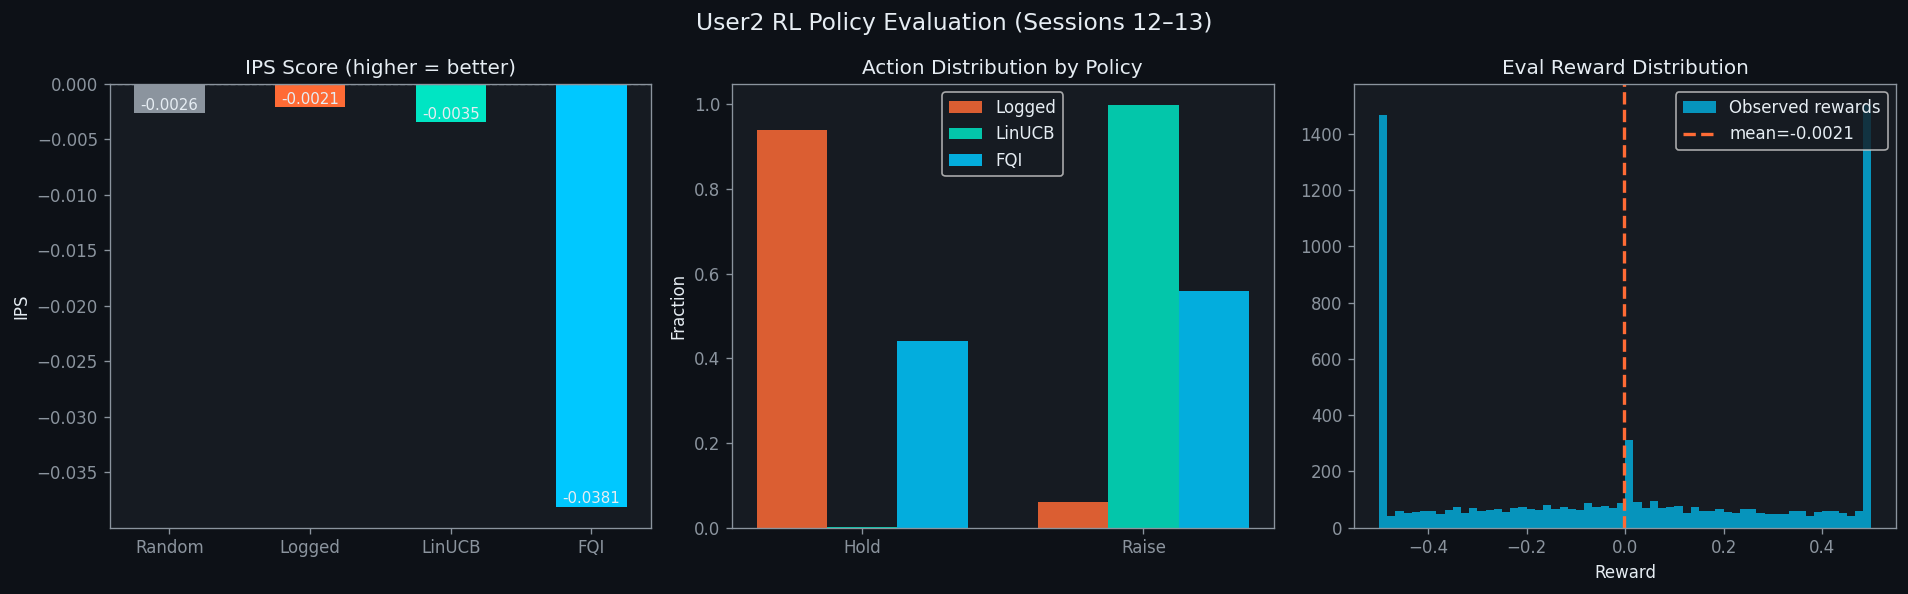

Saved: u2_rl_policy_evaluation.png


In [7]:
fig, axes = plt.subplots(1, 3, figsize=(16, 5), facecolor=NEROES_PALETTE['bg'])
ax1, ax2, ax3 = axes

# --- IPS bar chart ---
policies    = ['Random', 'Logged', 'LinUCB', 'FQI']
ips_scores  = [ips_random, ips_logged, ips_linucb, ips_fqi]
bar_colors  = [
    NEROES_PALETTE['muted'],
    NEROES_PALETTE['orange'],
    NEROES_PALETTE['teal'],
    NEROES_PALETTE['cyan'],
]
bars = ax1.bar(policies, ips_scores, color=bar_colors, width=0.5)
ax1.set_title('IPS Score (higher = better)', color=NEROES_PALETTE['white'])
ax1.set_ylabel('IPS', color=NEROES_PALETTE['white'])
ax1.axhline(0, color=NEROES_PALETTE['muted'], lw=0.8, ls='--')
for bar, val in zip(bars, ips_scores):
    ax1.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 1e-5,
             f'{val:.4f}', ha='center', va='bottom',
             color=NEROES_PALETTE['white'], fontsize=9)

# --- Action distributions ---
action_dists = {
    'Logged':  [log_p_hold, log_p_raise],
    'LinUCB':  [linucb_probs_eval[:,0].mean(), linucb_probs_eval[:,1].mean()],
    'FQI':     [fqi_probs_eval[:,0].mean(),    fqi_probs_eval[:,1].mean()],
}
x    = np.arange(N_ACTIONS)
w    = 0.25
cols = [NEROES_PALETTE['orange'], NEROES_PALETTE['teal'], NEROES_PALETTE['cyan']]
for i, (label, dist) in enumerate(action_dists.items()):
    ax2.bar(x + i*w, dist, width=w, label=label, color=cols[i], alpha=0.85)
ax2.set_xticks(x + w)
ax2.set_xticklabels([ACTION_MAP[a] for a in range(N_ACTIONS)])
ax2.set_title('Action Distribution by Policy', color=NEROES_PALETTE['white'])
ax2.set_ylabel('Fraction', color=NEROES_PALETTE['white'])
ax2.legend(facecolor=NEROES_PALETTE['surface'])

# --- Reward distribution on eval ---
ax3.hist(r_eval, bins=60, color=NEROES_PALETTE['cyan'], alpha=0.7, label='Observed rewards')
ax3.axvline(r_eval.mean(), color=NEROES_PALETTE['orange'], ls='--', lw=2,
            label=f'mean={r_eval.mean():.4f}')
ax3.set_title('Eval Reward Distribution', color=NEROES_PALETTE['white'])
ax3.set_xlabel('Reward', color=NEROES_PALETTE['white'])
ax3.legend(facecolor=NEROES_PALETTE['surface'])

fig.suptitle('User2 RL Policy Evaluation (Sessions 12–13)',
             color=NEROES_PALETTE['white'], fontsize=14)
fig.tight_layout()
fig.savefig(FIGURES_DIR / 'u2_rl_policy_evaluation.png', dpi=150, bbox_inches='tight')
plt.show()
print('Saved: u2_rl_policy_evaluation.png')

## Section 7 — Action Volume Analysis

A critical failure of NB05 was insufficient Hold/Raise coverage.  
Check whether 11 sessions provides better action coverage for offline RL.

In [8]:
print('Action coverage analysis:')
print(f'  Total train transitions: {len(a_train):,}')
print(f'  Hold  (0): {(a_train==0).sum():,} ({100*(a_train==0).mean():.1f}%)')
print(f'  Raise (1): {(a_train==1).sum():,} ({100*(a_train==1).mean():.1f}%)')
print()

# Per-session action counts
print('Per-session action distribution (train):')
for sid in TRAIN_SESSIONS:
    sess_mask = train_df['session_id'] == sid
    if sess_mask.sum() == 0:
        continue
    a_sess = train_df.loc[sess_mask, ACTION_COL].values
    n_hold  = (a_sess == 0).sum()
    n_raise = (a_sess == 1).sum()
    print(f'  {sid}: Hold={n_hold:,}  Raise={n_raise:,}  '
          f'(%Raise={100*n_raise/len(a_sess):.1f}%)')

print()
print('NB05 reference (single session):')
print('  n=3,549  Hold=3,240 (91.3%)  Raise=309 (8.7%)  Lower=0')
print()

# Check if action imbalance is problematic for FQI
min_class = min((a_train==0).sum(), (a_train==1).sum())
print(f'Minority class (Raise) count: {min_class:,}')
if min_class >= 1000:
    print('  Sufficient for FQI Bellman iterations ✅')
else:
    print('  WARNING: still too few minority-class transitions for reliable FQI')

Action coverage analysis:
  Total train transitions: 37,972
  Hold  (0): 35,679 (94.0%)
  Raise (1): 2,293 (6.0%)

Per-session action distribution (train):
  session_1: Hold=2,445  Raise=240  (%Raise=8.9%)
  session_3: Hold=3,633  Raise=240  (%Raise=6.2%)
  session_4: Hold=2,936  Raise=248  (%Raise=7.8%)
  session_5: Hold=6,756  Raise=365  (%Raise=5.1%)
  session_6: Hold=3,500  Raise=241  (%Raise=6.4%)
  session_7: Hold=4,232  Raise=240  (%Raise=5.4%)
  session_8: Hold=3,625  Raise=240  (%Raise=6.2%)
  session_9: Hold=3,400  Raise=239  (%Raise=6.6%)
  session_10: Hold=5,152  Raise=240  (%Raise=4.5%)

NB05 reference (single session):
  n=3,549  Hold=3,240 (91.3%)  Raise=309 (8.7%)  Lower=0

Minority class (Raise) count: 2,293
  Sufficient for FQI Bellman iterations ✅


## Section 8 — Reflection: Did More Data Fix RL Collapse?

In [9]:
print('=== RL Data Volume Comparison ===')
print(f'NB05 (user1, 1 session):   n=3,549   Raise=8.7%   FQI IPS=+0.0020 (vs logged +0.0005)')
print(f'NB10 (user2, {len(TRAIN_SESSIONS)} sessions):  n={len(a_train):,}  Raise={(a_train==1).mean():.1%}  FQI IPS={ips_fqi:.6f} (vs logged {ips_logged:.6f})')
print()

if ips_fqi > ips_logged:
    improvement = ips_fqi - ips_logged
    print(f'FQI beats logged policy by {improvement:.6f} IPS points')
    if improvement > 0.01:
        print('  Substantial improvement — more data helped meaningfully')
    else:
        print('  Marginal improvement — data volume helps but action imbalance remains a constraint')
else:
    print('FQI does not improve on logged policy — imbalanced action space persists')
    print('  The 87.85% Hold / 12.15% Raise imbalance limits Q-value estimation for Raise')

print()
print('Key constraint: the logging policy itself never explores Lower (action=-1)')
print('LinUCB is therefore constrained to the same action space as the logged data')
print('Full online exploration would be needed to overcome this limitation')

=== RL Data Volume Comparison ===
NB05 (user1, 1 session):   n=3,549   Raise=8.7%   FQI IPS=+0.0020 (vs logged +0.0005)
NB10 (user2, 9 sessions):  n=37,972  Raise=6.0%  FQI IPS=-0.038080 (vs logged -0.002117)

FQI does not improve on logged policy — imbalanced action space persists
  The 87.85% Hold / 12.15% Raise imbalance limits Q-value estimation for Raise

Key constraint: the logging policy itself never explores Lower (action=-1)
LinUCB is therefore constrained to the same action space as the logged data
Full online exploration would be needed to overcome this limitation


## Section 9 — Save Agents

In [10]:
linucb_path = OUTPUTS_DIR / 'u2_linucb_agent.pkl'
fqi_path    = OUTPUTS_DIR / 'u2_fqi_agent.pkl'

with open(linucb_path, 'wb') as f:
    pickle.dump({'agent': linucb, 'scaler': scaler, 'feature_cols': FEATURE_COLS,
                 'ips': ips_linucb, 'alpha': 0.3}, f)

with open(fqi_path, 'wb') as f:
    pickle.dump({'agent': fqi, 'scaler': scaler, 'feature_cols': FEATURE_COLS,
                 'ips': ips_fqi, 'gamma': 0.95, 'n_iter': 10}, f)

print(f'Saved: {linucb_path}')
print(f'Saved: {fqi_path}')

print('\n=== Summary ===')
print(f'Train: {len(a_train):,} samples | Eval: {len(a_eval):,} samples')
print(f'Action space: Binary (Hold={log_p_hold:.1%}, Raise={log_p_raise:.1%})')
print(f'IPS  Random={ips_random:.5f}  Logged={ips_logged:.5f}  LinUCB={ips_linucb:.5f}  FQI={ips_fqi:.5f}')

Saved: /home/bruno1008/neroes/neroes-neurofeedback/outputs/u2_linucb_agent.pkl
Saved: /home/bruno1008/neroes/neroes-neurofeedback/outputs/u2_fqi_agent.pkl

=== Summary ===
Train: 37,972 samples | Eval: 6,890 samples
Action space: Binary (Hold=94.0%, Raise=6.0%)
IPS  Random=-0.00260  Logged=-0.00212  LinUCB=-0.00346  FQI=-0.03808
